In [1]:
"""
13_visualizations_and_uncertainty.py

Figures and uncertainty estimates for the results chapter:
- ROC curves and Precision-Recall curves for the 4 baseline (train=2018,
  test=2019) models, combined on one plot each
- Feature importance bars (tree models) and coefficient bars (logistic
  regression)
- Paired bootstrap confidence intervals on ROC-AUC and PR-AUC, and on
  the pairwise difference between each model and the Logistic
  Regression baseline, so "model X beats model Y" claims are backed by
  an uncertainty estimate instead of a single point estimate.

07-10 don't persist prediction arrays to disk, so this notebook refits
the same 4 baseline models to get y_test/y_prob for plotting. Figures
are saved as PNGs under figures/ for direct use in the thesis document.
"""


'\n13_visualizations_and_uncertainty.py\n\nFigures and uncertainty estimates for the results chapter:\n- ROC curves and Precision-Recall curves for the 4 baseline (train=2018,\n  test=2019) models, combined on one plot each\n- Feature importance bars (tree models) and coefficient bars (logistic\n  regression)\n- Paired bootstrap confidence intervals on ROC-AUC and PR-AUC, and on\n  the pairwise difference between each model and the Logistic\n  Regression baseline, so "model X beats model Y" claims are backed by\n  an uncertainty estimate instead of a single point estimate.\n\n07-10 don\'t persist prediction arrays to disk, so this notebook refits\nthe same 4 baseline models to get y_test/y_prob for plotting. Figures\nare saved as PNGs under figures/ for direct use in the thesis document.\n'

In [2]:
from utils.load_data_features import load_data_features

df = load_data_features()


In [3]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from config import (
    FEATURES_BEHAVIORAL, FEATURES_FINANCIAL, RANDOM_STATE, TARGET,
    WINSOR_COLUMNS,
)
from utils.print_section import print_section
from utils.time_based_split import time_based_split
from utils.winsorizer import Winsorizer

FEATURE_SETS = {
    "Financial": FEATURES_FINANCIAL,
    "Financial + Behavioral": FEATURES_FINANCIAL + FEATURES_BEHAVIORAL,
}

# (result label, which model, which feature set) - same 4 baseline
# models as 07-10, train=2018 (config default), test=2019.
MODEL_SPECS = [
    ("Logistic Regression", "Logistic Regression", "Financial"),
    ("Random Forest", "Random Forest", "Financial"),
    ("XGBoost Financial", "XGBoost", "Financial"),
    ("XGBoost Financial + Behavioral", "XGBoost", "Financial + Behavioral"),
]


def make_pipeline(model_key, y_train):
    """Build the same pipeline as in 07-10, given which model to use."""
    if model_key == "Logistic Regression":
        model = LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE,
        )
    elif model_key == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=500, random_state=RANDOM_STATE,
            class_weight="balanced_subsample", n_jobs=-1,
        )
    elif model_key == "XGBoost":
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        model = XGBClassifier(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE, eval_metric="logloss",
        )
    else:
        raise ValueError(f"Unknown model_key: {model_key}")

    return Pipeline([
        ("winsorizer", Winsorizer(columns=WINSOR_COLUMNS)),
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model),
    ])


print_section("Refitting the 4 baseline (2018) models for plotting")

results = {}

for result_label, model_key, feature_set_key in MODEL_SPECS:
    features = FEATURE_SETS[feature_set_key]
    X_train, X_test, y_train, y_test = time_based_split(df, features, TARGET)

    pipeline = make_pipeline(model_key, y_train)
    pipeline.fit(X_train, y_train)

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results[result_label] = {
        "y_test": y_test.reset_index(drop=True),
        "y_prob": y_prob,
        "pipeline": pipeline,
        "features": features,
    }
    print(f"{result_label}: fitted, {len(y_test):,} test rows")



Refitting the 4 baseline (2018) models for plotting


Logistic Regression: fitted, 325,109 test rows


Random Forest: fitted, 325,109 test rows


XGBoost Financial: fitted, 325,109 test rows


XGBoost Financial + Behavioral: fitted, 325,109 test rows


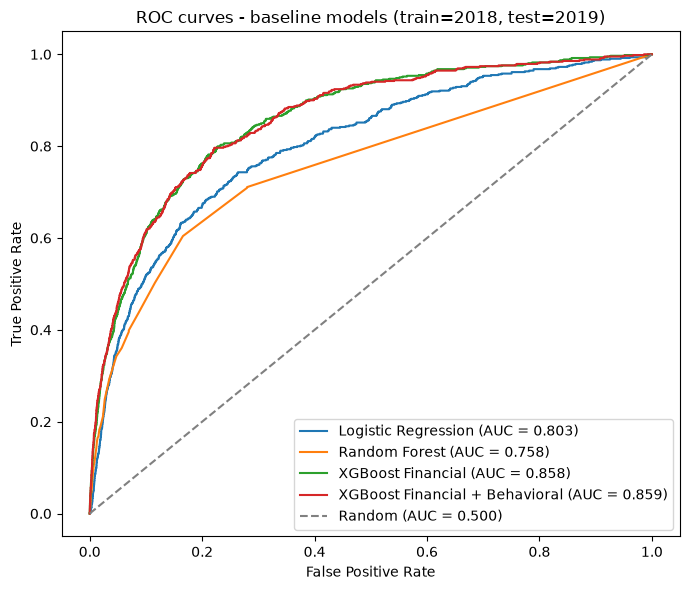

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

from config import FIGURES

FIGURES.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 6))

for label, r in results.items():
    fpr, tpr, _ = roc_curve(r["y_test"], r["y_prob"])
    auc = roc_auc_score(r["y_test"], r["y_prob"])
    ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves - baseline models (train=2018, test=2019)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "roc_curves.png", dpi=150)
plt.show()


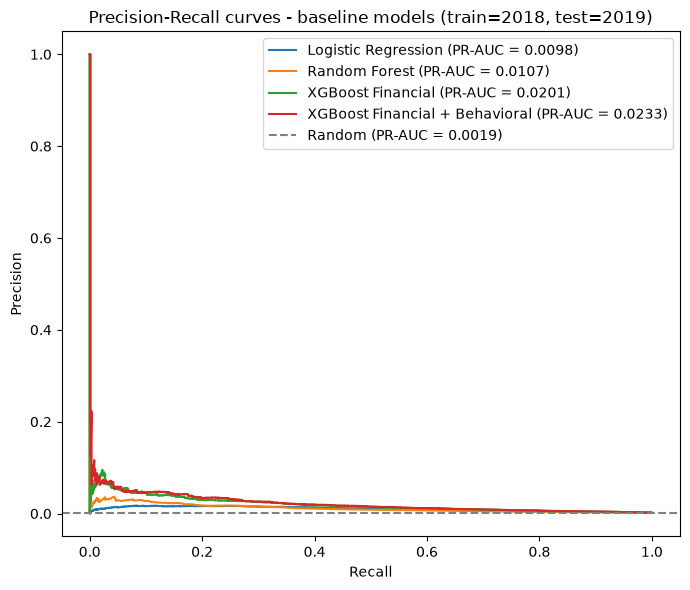

In [5]:
from sklearn.metrics import average_precision_score, precision_recall_curve

baseline_rate = results["Logistic Regression"]["y_test"].mean()

fig, ax = plt.subplots(figsize=(7, 6))

for label, r in results.items():
    precision, recall, _ = precision_recall_curve(r["y_test"], r["y_prob"])
    ap = average_precision_score(r["y_test"], r["y_prob"])
    ax.plot(recall, precision, label=f"{label} (PR-AUC = {ap:.4f})")

ax.axhline(
    baseline_rate, linestyle="--", color="grey",
    label=f"Random (PR-AUC = {baseline_rate:.4f})",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves - baseline models (train=2018, test=2019)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES / "pr_curves.png", dpi=150)
plt.show()


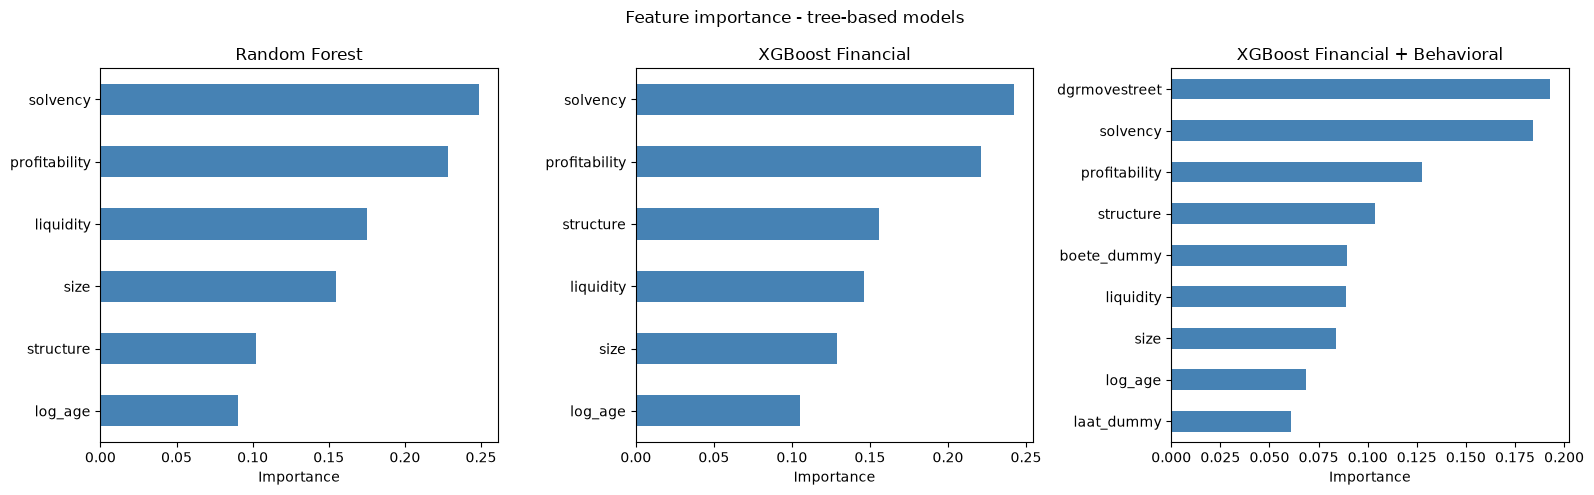

In [6]:
tree_models = ["Random Forest", "XGBoost Financial", "XGBoost Financial + Behavioral"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, label in zip(axes, tree_models):
    r = results[label]
    importances = pd.Series(
        r["pipeline"].named_steps["model"].feature_importances_,
        index=r["features"],
    ).sort_values()
    importances.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(label)
    ax.set_xlabel("Importance")

fig.suptitle("Feature importance - tree-based models")
fig.tight_layout()
fig.savefig(FIGURES / "feature_importance_trees.png", dpi=150)
plt.show()


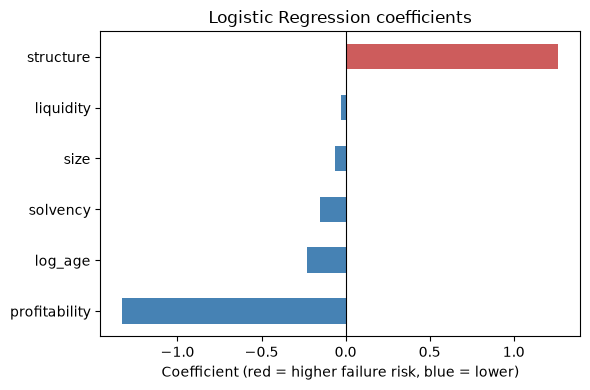

In [7]:
lr = results["Logistic Regression"]
coefs = pd.Series(
    lr["pipeline"].named_steps["model"].coef_[0],
    index=lr["features"],
).sort_values()

colors = ["indianred" if c > 0 else "steelblue" for c in coefs]

fig, ax = plt.subplots(figsize=(6, 4))
coefs.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression coefficients")
ax.set_xlabel("Coefficient (red = higher failure risk, blue = lower)")
fig.tight_layout()
fig.savefig(FIGURES / "logreg_coefficients.png", dpi=150)
plt.show()


In [8]:
# ------------------------------------------------------------------
# Paired bootstrap: resample the SAME test-row indices for every
# model on each iteration, so the 4 models are compared on identical
# resampled test sets. This lets us look at the distribution of the
# *difference* between two models, not just each model's own spread -
# a stronger basis for "model X is better than model Y" than comparing
# two separate confidence intervals.
# ------------------------------------------------------------------
import numpy as np

print_section("Bootstrap confidence intervals (paired, B=1000)")

N_BOOT = 1000
rng = np.random.default_rng(RANDOM_STATE)

y_test_ref = results["Logistic Regression"]["y_test"].values
n = len(y_test_ref)

for label, r in results.items():
    assert np.array_equal(r["y_test"].values, y_test_ref), (
        f"{label} does not share the same test rows - paired bootstrap assumption violated"
    )

boot_roc = {label: np.empty(N_BOOT) for label in results}
boot_pr = {label: np.empty(N_BOOT) for label in results}

for b in range(N_BOOT):
    idx = rng.integers(0, n, size=n)
    y_boot = y_test_ref[idx]
    for label, r in results.items():
        prob_boot = r["y_prob"][idx]
        boot_roc[label][b] = roc_auc_score(y_boot, prob_boot)
        boot_pr[label][b] = average_precision_score(y_boot, prob_boot)

print(f"Done: {N_BOOT} bootstrap resamples x {len(results)} models.")



Bootstrap confidence intervals (paired, B=1000)


Done: 1000 bootstrap resamples x 4 models.


In [9]:
print_section("95% confidence intervals per model")

ci_rows = []
for label, r in results.items():
    roc_point = roc_auc_score(y_test_ref, r["y_prob"])
    pr_point = average_precision_score(y_test_ref, r["y_prob"])
    roc_lo, roc_hi = np.percentile(boot_roc[label], [2.5, 97.5])
    pr_lo, pr_hi = np.percentile(boot_pr[label], [2.5, 97.5])
    ci_rows.append({
        "model": label,
        "roc_auc": roc_point,
        "roc_auc_ci_low": roc_lo,
        "roc_auc_ci_high": roc_hi,
        "pr_auc": pr_point,
        "pr_auc_ci_low": pr_lo,
        "pr_auc_ci_high": pr_hi,
    })

ci_df = pd.DataFrame(ci_rows)
print(ci_df.round(4).to_string(index=False))

print_section("Pairwise differences vs. Logistic Regression")

diff_rows = []
for label in results:
    if label == "Logistic Regression":
        continue
    diff_roc = boot_roc[label] - boot_roc["Logistic Regression"]
    diff_pr = boot_pr[label] - boot_pr["Logistic Regression"]
    diff_rows.append({
        "comparison": f"{label} - Logistic Regression",
        "roc_auc_diff": diff_roc.mean(),
        "roc_auc_diff_ci_low": np.percentile(diff_roc, 2.5),
        "roc_auc_diff_ci_high": np.percentile(diff_roc, 97.5),
        "pr_auc_diff": diff_pr.mean(),
        "pr_auc_diff_ci_low": np.percentile(diff_pr, 2.5),
        "pr_auc_diff_ci_high": np.percentile(diff_pr, 97.5),
    })

diff_df = pd.DataFrame(diff_rows)
print(diff_df.round(4).to_string(index=False))
print(
    "\n(A 95% CI for the difference that excludes 0 means the gap is "
    "unlikely to be due to test-set sampling noise alone.)"
)



95% confidence intervals per model


                         model  roc_auc  roc_auc_ci_low  roc_auc_ci_high  pr_auc  pr_auc_ci_low  pr_auc_ci_high
           Logistic Regression   0.8026          0.7841           0.8216  0.0098         0.0084          0.0117
                 Random Forest   0.7576          0.7369           0.7771  0.0107         0.0088          0.0134
             XGBoost Financial   0.8584          0.8434           0.8719  0.0201         0.0163          0.0261
XGBoost Financial + Behavioral   0.8586          0.8438           0.8723  0.0233         0.0183          0.0320

Pairwise differences vs. Logistic Regression
                                          comparison  roc_auc_diff  roc_auc_diff_ci_low  roc_auc_diff_ci_high  pr_auc_diff  pr_auc_diff_ci_low  pr_auc_diff_ci_high
                 Random Forest - Logistic Regression       -0.0456              -0.0648               -0.0259       0.0010             -0.0008               0.0032
             XGBoost Financial - Logistic Regression        0.0553

In [10]:
print_section("XGBoost Financial vs. XGBoost Financial + Behavioral")

diff_roc_xgb = boot_roc["XGBoost Financial + Behavioral"] - boot_roc["XGBoost Financial"]
diff_pr_xgb = boot_pr["XGBoost Financial + Behavioral"] - boot_pr["XGBoost Financial"]

roc_ci = (np.percentile(diff_roc_xgb, 2.5), np.percentile(diff_roc_xgb, 97.5))
pr_ci = (np.percentile(diff_pr_xgb, 2.5), np.percentile(diff_pr_xgb, 97.5))

print(f"ROC-AUC difference: {diff_roc_xgb.mean():+.4f}, 95% CI [{roc_ci[0]:+.4f}, {roc_ci[1]:+.4f}]")
print(f"PR-AUC difference : {diff_pr_xgb.mean():+.4f}, 95% CI [{pr_ci[0]:+.4f}, {pr_ci[1]:+.4f}]")

roc_significant = not (roc_ci[0] <= 0 <= roc_ci[1])
pr_significant = not (pr_ci[0] <= 0 <= pr_ci[1])

print(f"\nROC-AUC gap statistically significant (95%): {roc_significant}")
print(f"PR-AUC gap statistically significant (95%): {pr_significant}")



XGBoost Financial vs. XGBoost Financial + Behavioral
ROC-AUC difference: +0.0002, 95% CI [-0.0034, +0.0038]
PR-AUC difference : +0.0034, 95% CI [-0.0008, +0.0090]

ROC-AUC gap statistically significant (95%): False
PR-AUC gap statistically significant (95%): False
